# Task 2: Bayesian Change Point Modeling and Insight Generation

## Brent Crude Oil Price Structural Break Analysis

### Objective

The objective of this task is to apply Bayesian Change Point Detection to identify structural breaks in Brent crude oil prices and quantify their impact.

The analysis investigates whether historical oil price behavior changed significantly due to major geopolitical, economic, or market events.

The workflow includes:

- Data preparation
- Exploratory time series analysis
- Log return analysis
- Bayesian Change Point Modeling using PyMC
- MCMC sampling
- Posterior inference
- Structural break identification
- Historical event comparison
- Economic interpretation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import arviz as az


import sys
sys.path.append("../")


print("Libraries loaded")

Libraries loaded


In [2]:
from src.data_loader import (
    load_brent_data,
    convert_date_column
)


from src.preprocessing import (
    create_price_features,
    prepare_model_data
)


from src.eda import (
    dataset_overview,
    summary_statistics
)


from src.visualization import (
    plot_price_history,
    plot_change_point,
    plot_Log_Return_Analysis,
    plot_rolling_volatility    
)


from src.bayesian_model import (
    build_change_point_model,
    build_change_point_model_fast,
    run_sampler
)


from src.change_point import (
    extract_change_point,
    quantify_impact
)


from src.event_analysis import (
    find_nearest_event
)


print("Project modules loaded")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Project modules loaded


In [3]:
DATA_PATH="../data/brent_processed.csv"


df = load_brent_data(
    DATA_PATH
)


df = convert_date_column(
    df
)


df.head()

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Volatility
0,1987-05-20,18.63,2.924773,NaN,NaN,NaN
1,1987-05-21,18.45,2.915064,-0.18,-0.009709,NaN
2,1987-05-22,18.55,2.920470,0.10,0.005405,NaN
3,1987-05-25,18.60,2.923162,0.05,0.002692,NaN
4,1987-05-26,18.63,2.924773,0.03,0.001612,NaN


In [4]:
dataset_overview(df)

{'rows': 9011,
 'columns': 6,
 'column_names': ['Date',
  'Price',
  'Log_Price',
  'Price_Change',
  'Log_Return',
  'Rolling_Volatility'],
 'missing_values': {'Date': 0,
  'Price': 0,
  'Log_Price': 0,
  'Price_Change': 1,
  'Log_Return': 1,
  'Rolling_Volatility': 30},
 'duplicates': np.int64(0)}

In [5]:
summary_statistics(df)

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Volatility
count,9011,9011.000000,9011.000000,9010.000000,9010.000000,8981.000000
mean,2005-02-10 23:46:53.760958,48.420782,3.638729,0.008320,0.000179,0.021564
min,1987-05-20 00:00:00,9.100000,2.208274,-16.600000,-0.643699,0.005807
25%,1996-03-20 12:00:00,19.050000,2.947067,-0.390000,-0.011154,0.014916
50%,2005-02-02 00:00:00,38.570000,3.652475,0.020000,0.000402,0.019305
75%,2014-01-09 12:00:00,70.090000,4.249780,0.450000,0.012127,0.024429
max,2022-11-14 00:00:00,143.950000,4.969466,10.450000,0.412023,0.187314
std,NaN,32.860110,0.707122,1.216227,0.025532,0.013661


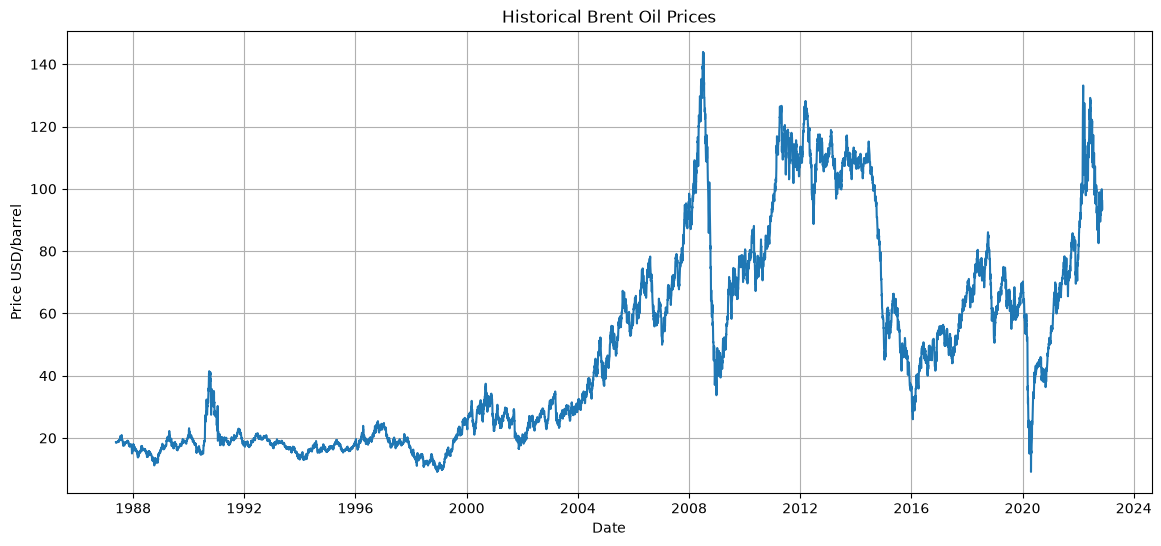

In [6]:
plot_price_history(df)

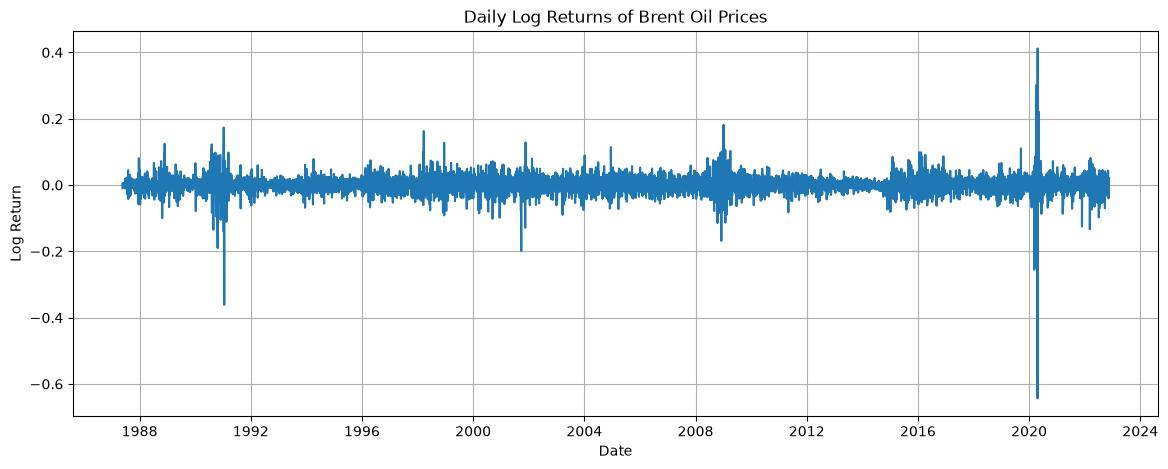

In [7]:
plot_Log_Return_Analysis(df)

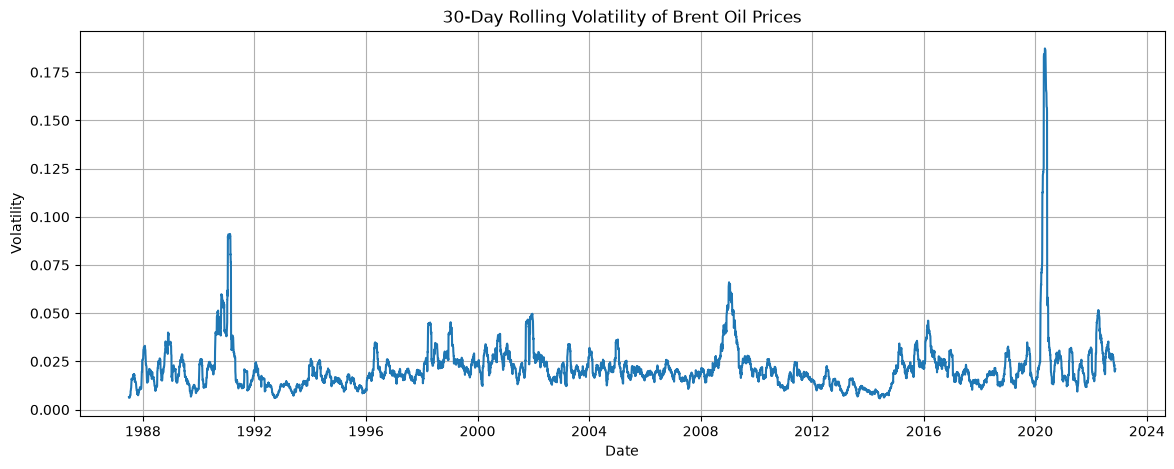

In [8]:
plot_rolling_volatility(df)

In [9]:
#log_returns = prepare_model_data(
    #df,
   # "Price"
#)


#len(prices)

In [10]:
# Remove the first NaN created by differencing
log_returns = df["Log_Return"].dropna().values

print(log_returns[:10])
print(f"Number of observations: {len(log_returns)}")

[-0.00970881  0.00540542  0.00269179  0.0016116  -0.0016116   0.
 -0.00107585  0.00376041  0.00160729  0.00374032]
Number of observations: 9010


In [11]:
#model = build_change_point_model(
   # prices
#)

# 1. Make sure the Date column is in actual datetime format
df['Date'] = pd.to_datetime(df['Date'])


# 2. Set the Date column as the Index
#df = df.set_index('Date')
#df_weekly = df['Log_Return'].resample('W').mean().dropna()

monthly_df = (
    df.set_index("Date")
      .resample("ME")   # or "M" depending on your pandas version
      .mean(numeric_only=True)
      .reset_index()
)

monthly_df.head()
#print(f"Number of observations: {len(monthly_df)}")


,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Volatility
0,1987-05-31,18.580000,2.922081,-0.007143,-0.000384,NaN
1,1987-06-30,18.860476,2.937030,0.023810,0.001265,NaN
2,1987-07-31,19.856522,2.988282,0.041304,0.002113,0.007836
3,1987-08-31,18.979524,2.942236,-0.066667,-0.003450,0.016222
4,1987-09-30,18.313182,2.907501,-0.006818,-0.000367,0.016111


In [12]:
#monthly_df = create_price_features(monthly_df)

#log = prepare_model_data(monthly_df, "log_returns")

model = build_change_point_model_fast(prices=monthly_df["Price"].values)

model

tau_latent ~ Uniform(0, 1)
       mu1 ~ Normal(3.64, 1.41)
       mu2 ~ Normal(3.64, 1.41)
     sigma ~ HalfNormal(0, 0.707)
       tau ~ Deterministic(f(tau_latent))
      mean ~ Deterministic(f(mu2, mu1, tau_latent))
       obs ~ Normal(mean, sigma)

In [13]:

#model = build_change_point_model(df_weekly)
#fast_model = build_change_point_model_fast(df_weekly.values)

#model = build_change_point_model_fast(data_to_use)

#fast_model

In [14]:
import time

print("=" * 60)
print("STARTING MCMC SAMPLING")
print("=" * 60)

start_time = time.time()

trace = run_sampler(
    build_change_point_model_fast(prices=monthly_df["Price"].values),
    draws=1000,
    tune=1000
)

elapsed = time.time() - start_time
print("=" * 60)
print(f"SAMPLING COMPLETED in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print("=" * 60)

STARTING MCMC SAMPLING


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau_latent, mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5204 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


SAMPLING COMPLETED in 5207.2 seconds (86.8 minutes)


In [15]:
summary = az.summary(
    trace
)


summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu1,2.984,0.023,2.944,3.027,0.000,0.000,2192.0,2079.0,1.00
mu2,4.251,0.022,4.210,4.293,0.001,0.000,1723.0,1950.0,1.00
tau_latent,0.480,0.004,0.473,0.485,0.000,0.000,392.0,416.0,1.02
sigma,0.318,0.011,0.298,0.339,0.000,0.000,2503.0,2321.0,1.00
tau,204.940,1.513,201.924,207.113,0.081,0.048,392.0,416.0,1.02
...,...,...,...,...,...,...,...,...,...
mean[422],4.251,0.022,4.210,4.293,0.001,0.000,1723.0,1950.0,1.00
mean[423],4.251,0.022,4.210,4.293,0.001,0.000,1723.0,1950.0,1.00
mean[424],4.251,0.022,4.210,4.293,0.001,0.000,1723.0,1950.0,1.00
mean[425],4.251,0.022,4.210,4.293,0.001,0.000,1723.0,1950.0,1.00


In [16]:
summary[
    [
        "mean",
        "sd",
        "ess_bulk",
        "r_hat"
    ]
]

,mean,sd,ess_bulk,r_hat
mu1,2.984,0.023,2192.0,1.00
mu2,4.251,0.022,1723.0,1.00
tau_latent,0.480,0.004,392.0,1.02
sigma,0.318,0.011,2503.0,1.00
tau,204.940,1.513,392.0,1.02
...,...,...,...,...
mean[422],4.251,0.022,1723.0,1.00
mean[423],4.251,0.022,1723.0,1.00
mean[424],4.251,0.022,1723.0,1.00
mean[425],4.251,0.022,1723.0,1.00


In [17]:
if (summary["r_hat"] <= 1.01).all():

    print(
        "Model converged successfully"
    )

else:

    print(
        "Check convergence"
    )

Check convergence


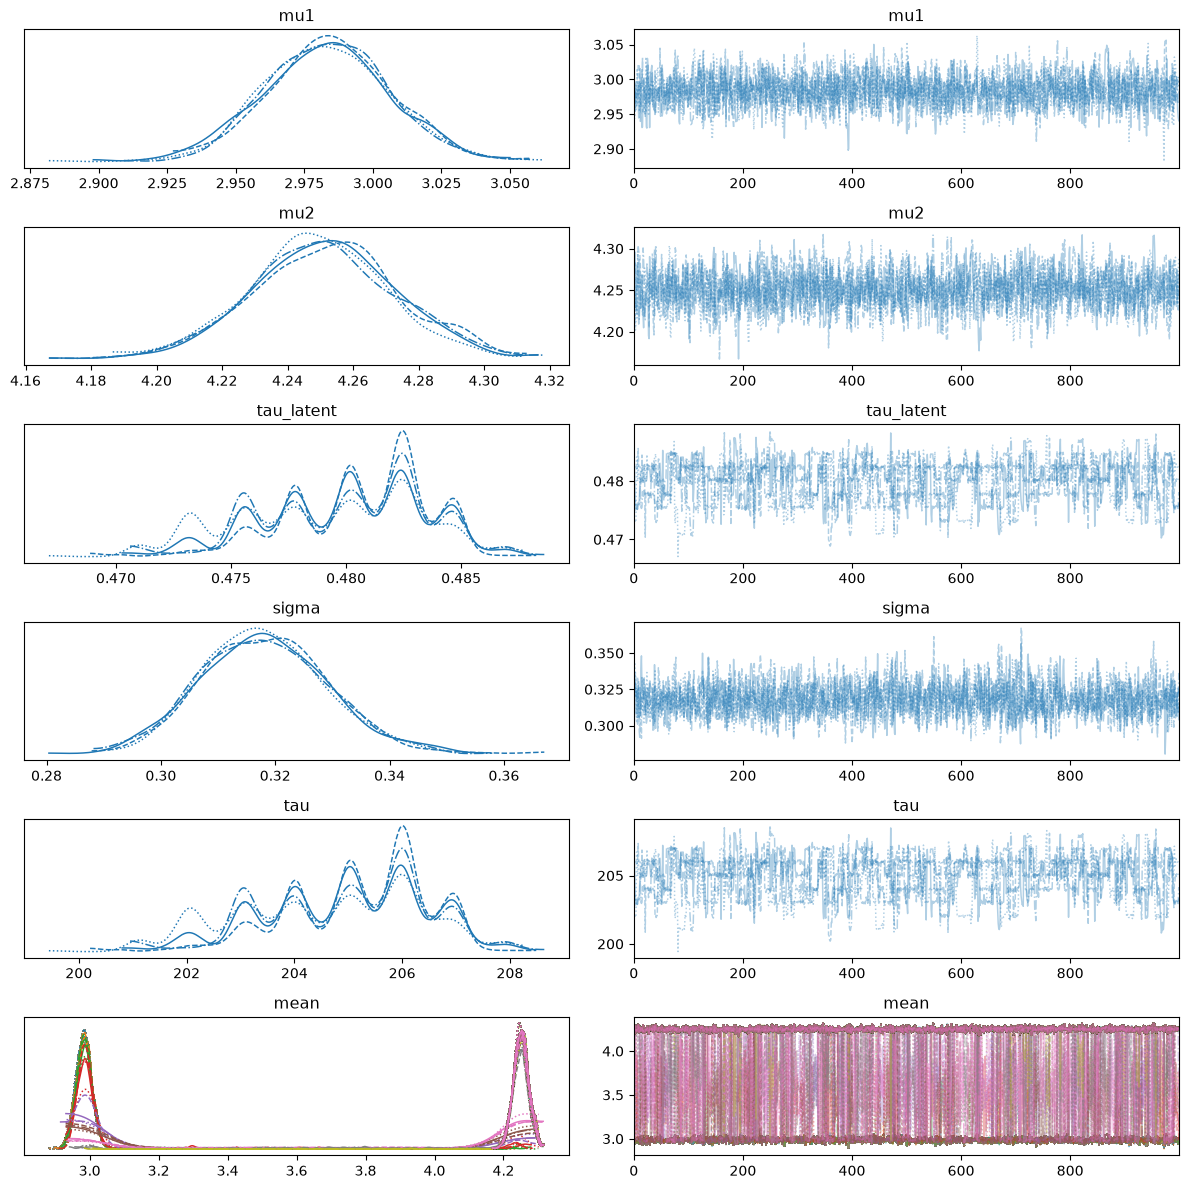

In [18]:
az.plot_trace(
    trace
)

plt.tight_layout()

plt.show()

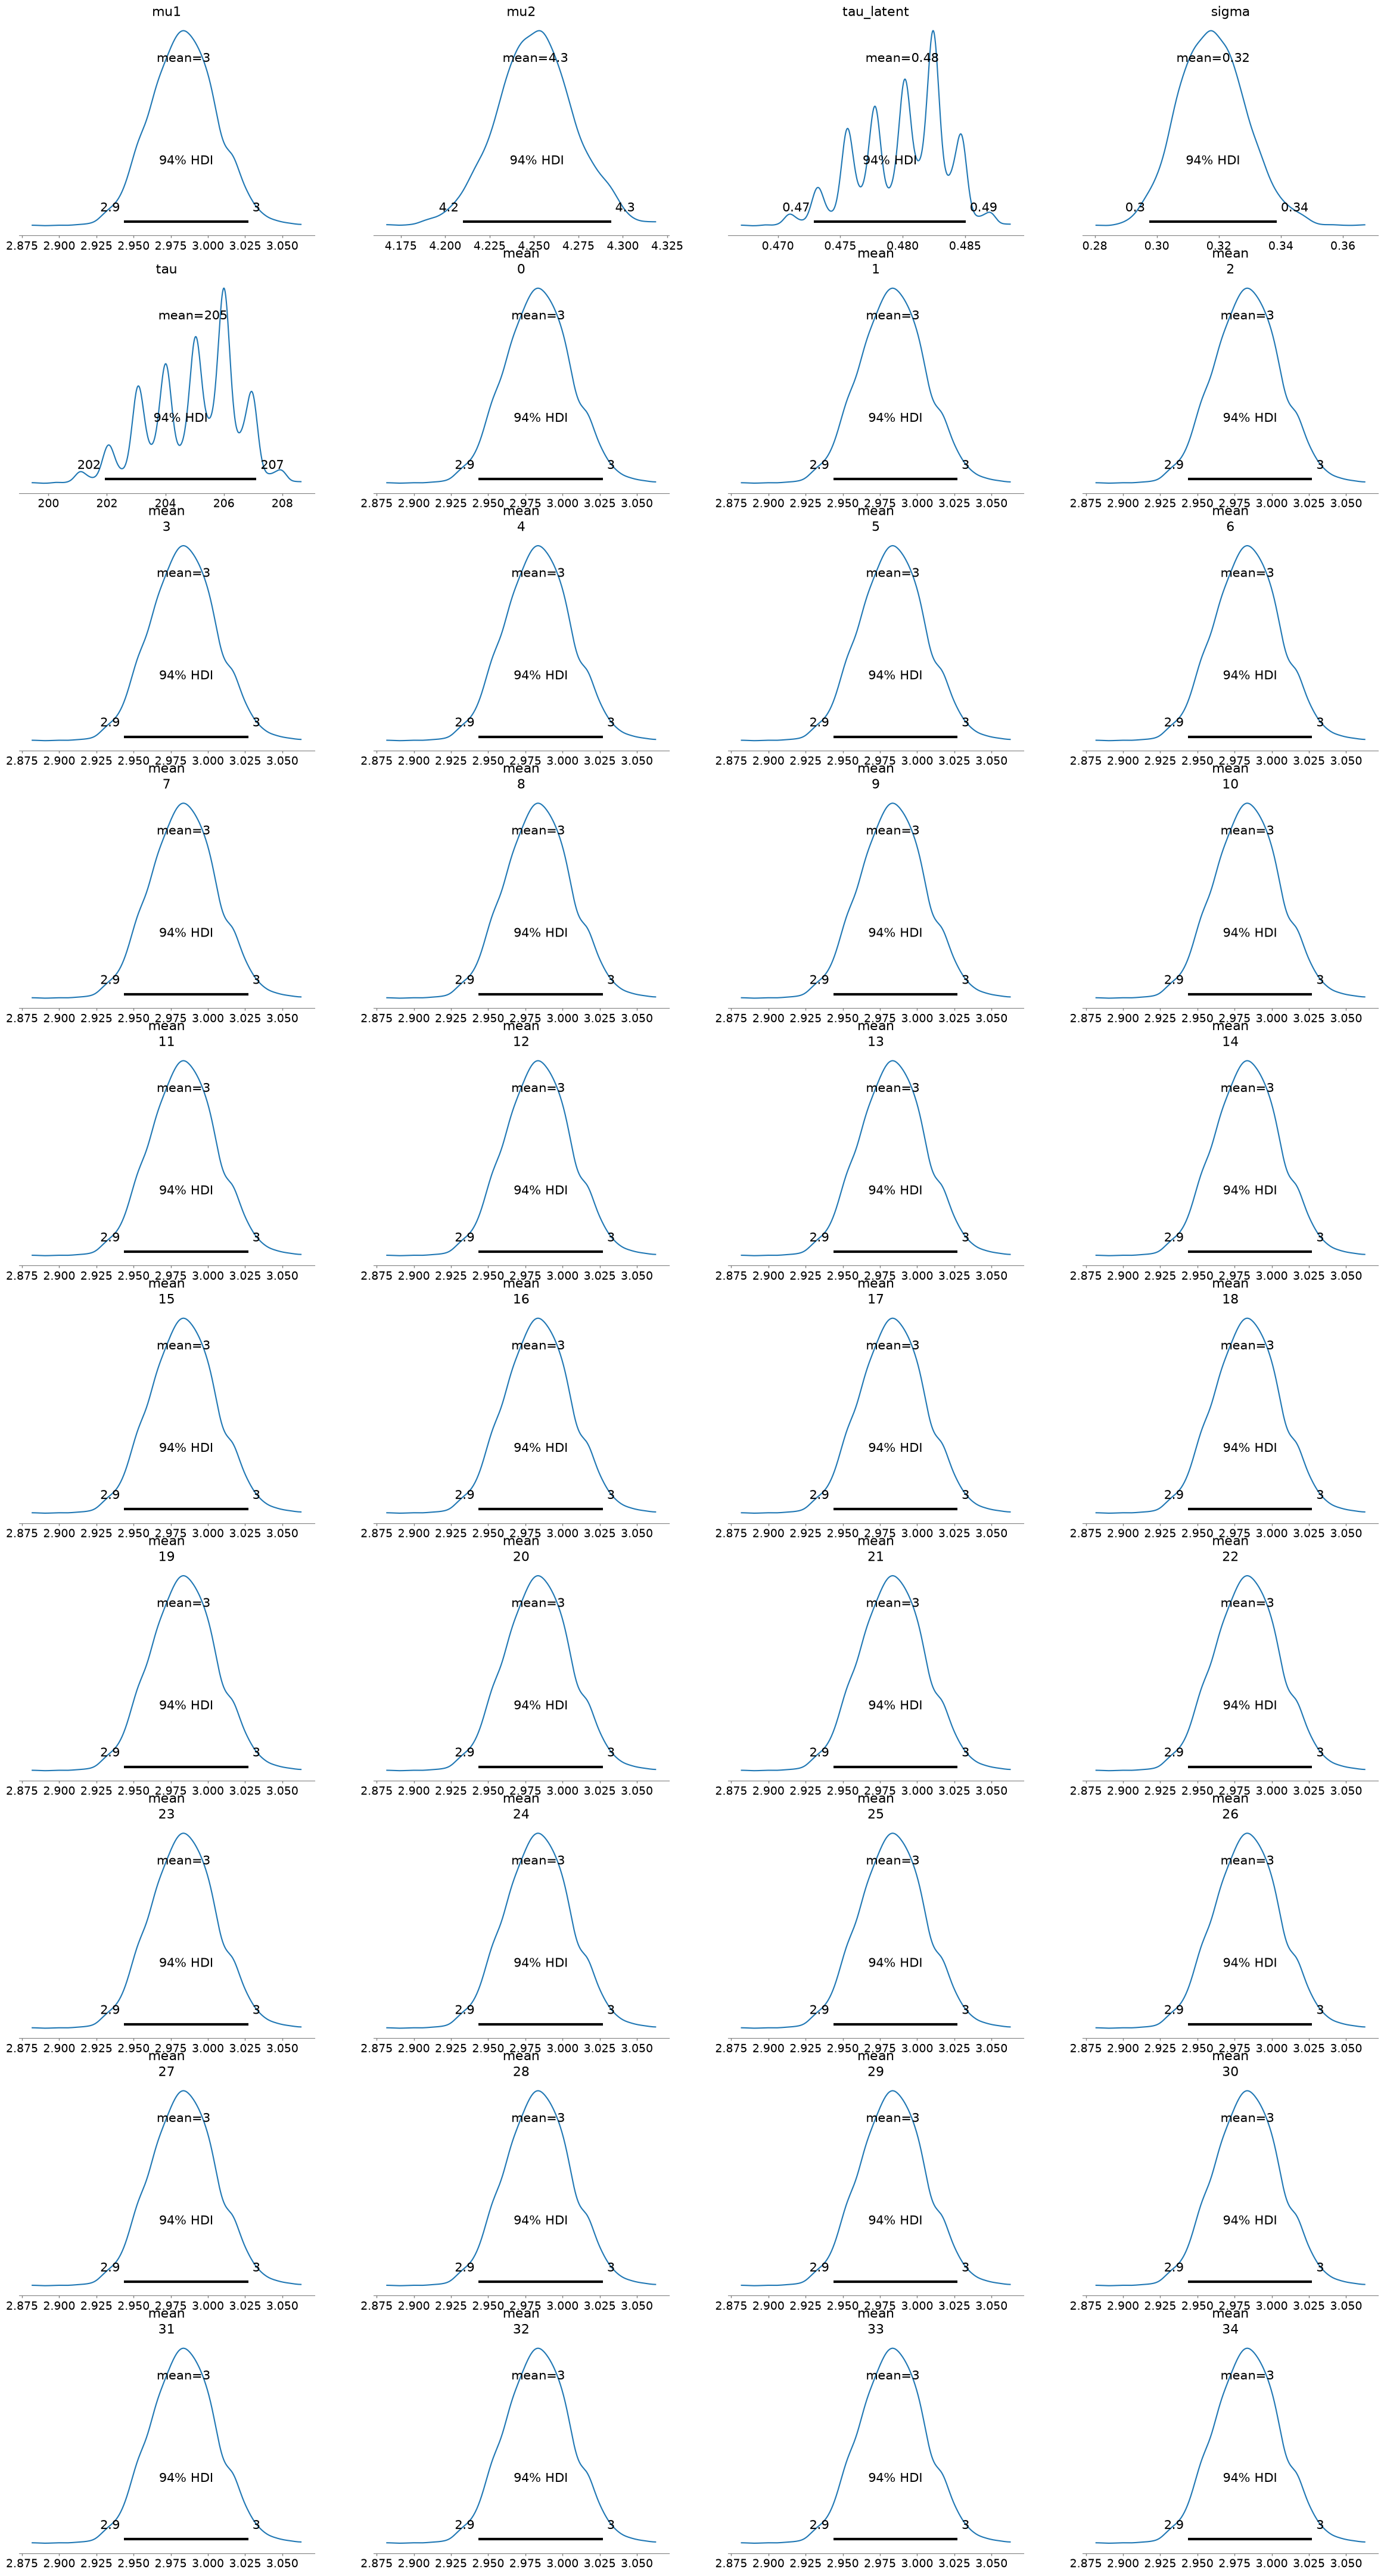

In [19]:
az.plot_posterior(
    trace
)

plt.show()

In [20]:
tau = extract_change_point(
    trace
)


print(
    "Change point index:",
    tau
)

Change point index: 205


In [21]:
change_date = df.iloc[tau]["Date"]


print(
    "Estimated change point date:",
    change_date
)

Estimated change point date: 1988-03-09 00:00:00


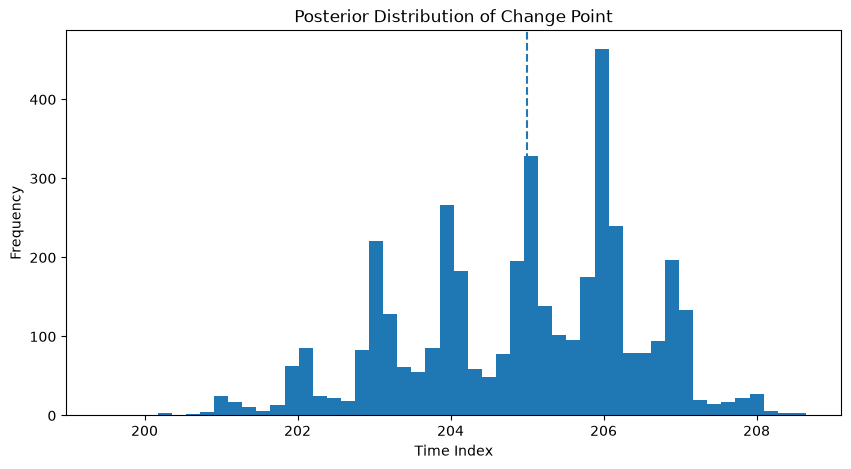

In [22]:
tau_samples = (
    trace
    .posterior["tau"]
    .values
    .flatten()
)


plt.figure(figsize=(10,5))


plt.hist(
    tau_samples,
    bins=50
)


plt.axvline(
    tau,
    linestyle="--"
)


plt.title(
    "Posterior Distribution of Change Point"
)


plt.xlabel(
    "Time Index"
)


plt.ylabel(
    "Frequency"
)


plt.show()

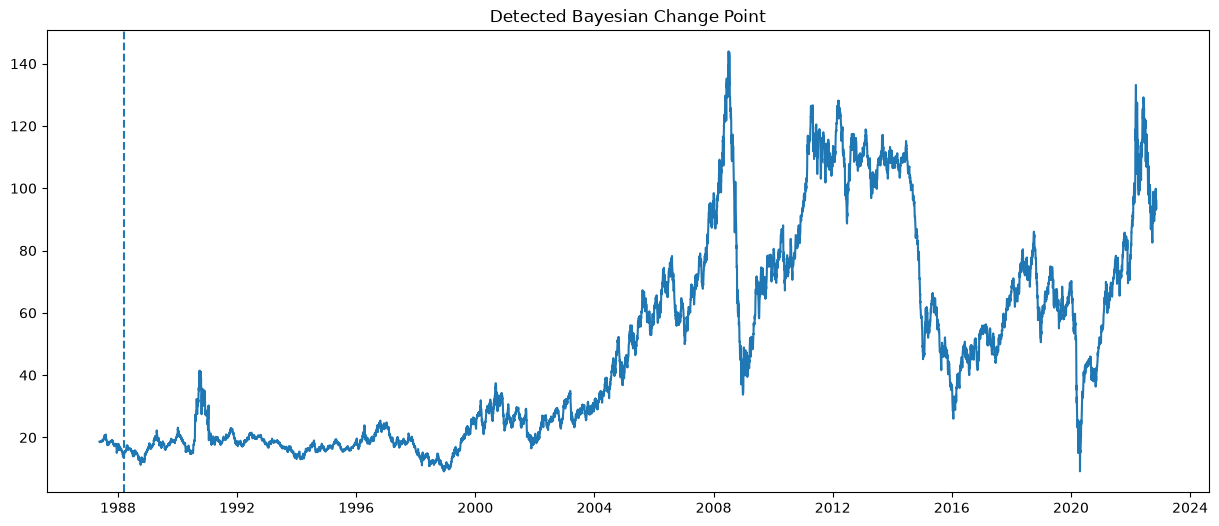

In [23]:
plot_change_point(
    df,
    change_date
)

In [24]:
impact = quantify_impact(
    df,
    tau
)


impact

{'before_mean': np.float64(17.949365853658534),
 'after_mean': np.float64(49.1301442198501),
 'percentage_change': np.float64(173.71520877344054)}

In [25]:
before = impact["before_mean"]

after = impact["after_mean"]

change = impact["percentage_change"]


print(
f"""
The Bayesian model detected a structural break around {change_date.date()}.

Before the change point:
Average Brent price = ${before:.2f}

After the change point:
Average Brent price = ${after:.2f}

Estimated impact:
{change:.2f}% change in average price.
"""
)


The Bayesian model detected a structural break around 1988-03-09.

Before the change point:
Average Brent price = $17.95

After the change point:
Average Brent price = $49.13

Estimated impact:
173.72% change in average price.



In [26]:
events = pd.read_csv(
    "../data/events.csv",
    parse_dates=["Date"]
)


events

,Date,Event_Name,Category,Description,Expected_Impact
0,1990-08-02,Iraq Invades Kuwait,War,Iraq's invasion of Kuwait disrupted oil suppli...,Strong price increase
1,1991-01-17,Operation Desert Storm,War,Coalition forces launched military operations ...,High market volatility
2,1997-07-02,Asian Financial Crisis,Economic Crisis,Financial crisis reduced oil demand across Asi...,Price decrease
3,1998-12-16,Operation Desert Fox,War,U.S. and U.K. airstrikes against Iraq increase...,Temporary price increase
4,2001-09-11,September 11 Terrorist Attacks,Political,Terrorist attacks in the United States created...,Short-term volatility
5,2003-03-20,Iraq War Begins,War,U.S.-led invasion of Iraq raised concerns abou...,Price increase
6,2008-09-15,Global Financial Crisis,Economic Crisis,Collapse of Lehman Brothers triggered a global...,Sharp price decline
7,2010-12-17,Arab Spring Begins,Political,Political unrest across the Middle East and No...,Increased volatility
8,2011-02-15,Libyan Civil War,War,Conflict in Libya disrupted oil production and...,Price increase
9,2014-11-27,OPEC Maintains Production,OPEC Decision,OPEC decided not to cut production despite ove...,Significant price decline


In [27]:
nearest = find_nearest_event(
    events,
    change_date
)


nearest

Date                                             1990-08-02 00:00:00
Event_Name                                       Iraq Invades Kuwait
Category                                                         War
Description        Iraq's invasion of Kuwait disrupted oil suppli...
Expected_Impact                                Strong price increase
Difference                                         876 days 00:00:00
Name: 0, dtype: object